In [9]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from sklearn.linear_model import Lasso

reservoirpy.set_seed(42)

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..',)))
from lib.utils.reservoirpy import *

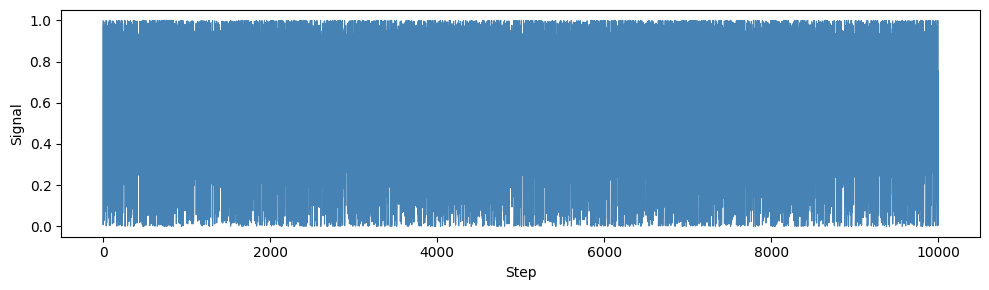

In [13]:
# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../data/chaotic_data/logistic_map.csv', delimiter=',')
dataset = dataset[:, ]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)

# One-step supervised pairs
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len = 2000
test_start = 2000
test_len = 1000

regression_model = "lasso"   # options: ridge, lasso
seed = 42

# Training/test windows
X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]

X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]


# ==========================================================
# PARAMETER GRID
# ==========================================================
param_grid = {
    "normalization":          ["minmax01"],  # options: none, zscore, minmax01, minmax11
    "train_warmup":           [100],
    "test_warmup":            [300],
    "units":                  [500, 1000, 1500],
    "reservoir_connectivity": [0.05, 0.2, 1.0],
    "sr":                     [0.8, 1.0, 1.2, 1.3],
    "lr":                     [0.1, 0.3, 0.5],
    "input_scaling":          [0.1, 0.5, 1.0],
    "regression":             [1e-4, 1e-3, 1e-2, 1e-1],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_esn(
    normalization,
    train_warmup,
    test_warmup,
    units,
    reservoir_connectivity,
    sr,
    lr,
    input_scaling,
    regression,
    seed=42
):
    """
    Build, train, synchronize, and run closed-loop prediction.
    Return NRMSE in scaled space for hyperparameter search.
    """
    try:
        # Safety
        if test_warmup >= test_len:
            return np.inf

        # -------------------------
        # Fit scaler on training inputs only
        # -------------------------
        scaler = fit_scaler(X_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test = transform_array(X_test_raw, scaler)
        Y_test = transform_array(Y_test_raw, scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        # Safety
        if train_warmup >= len(X_train):
            return np.inf

        # -------------------------
        # Reservoir
        # -------------------------
        reservoir = Reservoir(
            units=int(units),
            lr=lr,
            W=uniform(
                low=-0.5,
                high=0.5,
                connectivity=reservoir_connectivity,
                sr=sr
            ),
            Win=uniform(
                low=-0.5 * input_scaling,
                high=0.5 * input_scaling,
                connectivity=1.0
            ),
            bias=uniform(
                low=-0.5,
                high=0.5,
                connectivity=1.0
            ),
            activation="tanh",
            seed=seed
        )

        if regression_model == "ridge":
            readout = Ridge(ridge=regression)
        else:
            readout = ScikitLearnNode(
                model=Lasso,
                alpha=regression,
                max_iter=50000,
                tol=1e-3
            )

        esn = reservoir >> readout

        # -------------------------
        # Train
        # -------------------------
        esn.fit(X_train, Y_train, warmup=train_warmup)

        # -------------------------
        # Test: reset + synchronize + closed loop
        # -------------------------
        esn.reset()

        if test_warmup > 0:
            esn.run(X_test[:test_warmup])

        current_input = X_test[test_warmup:test_warmup + 1]
        Y_pred_scaled = []

        for _ in range(pred_len):
            pred = esn.run(current_input)
            pred = np.asarray(pred).reshape(1, -1)
            Y_pred_scaled.append(pred[0, 0])
            current_input = pred

        Y_pred_scaled = np.array(Y_pred_scaled)

        # Divergence check
        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf

        nrmse = rmse / denom
        return nrmse

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params, seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(
            f"[{i+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Regression model    : {regression_model}")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'norm':>8}  {'tr_wu':>5}  {'te_wu':>5}  "
    f"{'units':>5}  {'conn':>5}  {'sr':>4}  {'lr':>4}  "
    f"{'in_sc':>6}  {'reg':>8}  {'NRMSE':>10}"
)
print("-" * 100)

for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{r['normalization']:>8s}  "
        f"{r['train_warmup']:5d}  "
        f"{r['test_warmup']:5d}  "
        f"{int(r['units']):5d}  "
        f"{r['reservoir_connectivity']:5.2f}  "
        f"{r['sr']:4.2f}  "
        f"{r['lr']:4.1f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# REBUILD BEST MODEL
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])

X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_reservoir = Reservoir(
    units=int(best_params["units"]),
    lr=best_params["lr"],
    W=uniform(
        low=-0.5,
        high=0.5,
        connectivity=best_params["reservoir_connectivity"],
        sr=best_params["sr"]
    ),
    Win=uniform(
        low=-0.5 * best_params["input_scaling"],
        high=0.5 * best_params["input_scaling"],
        connectivity=1.0
    ),
    bias=uniform(
        low=-0.5,
        high=0.5,
        connectivity=1.0
    ),
    activation="tanh",
    seed=seed
)

if regression_model == "ridge":
    best_readout = Ridge(ridge=best_params["regression"])
else:
    best_readout = ScikitLearnNode(
        model=Lasso,
        alpha=best_params["regression"],
        max_iter=10000
    )

best_esn = best_reservoir >> best_readout

# Train
best_esn.fit(
    X_train_best,
    Y_train_best,
    warmup=best_params["train_warmup"]
)

# Test
best_esn.reset()

if best_params["test_warmup"] > 0:
    best_esn.run(X_test_best[:best_params["test_warmup"]])

Y_pred_best_scaled = []
current_input = X_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + 1
]

for _ in range(best_pred_len):
    pred = best_esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred_best_scaled.append(pred[0, 0])
    current_input = pred

Y_pred_best_scaled = np.array(Y_pred_best_scaled).reshape(-1, 1)
Y_true_best_scaled = Y_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len
]

# Inverse transform for final metrics / plot
Y_pred_best = inverse_transform_array(Y_pred_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(Y_true_best_scaled, best_scaler).ravel()

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_best)

print("\nFinal best-model metrics in original scale:")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2
)

ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end"
)

ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="ESN closed-loop prediction"
)

ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"norm={best_params['normalization']}, "
    f"units={int(best_params['units'])}, "
    f"conn={best_params['reservoir_connectivity']}, "
    f"sr={best_params['sr']}, "
    f"lr={best_params['lr']}, "
    f"in_sc={best_params['input_scaling']}, "
    f"reg={best_params['regression']:.0e}, "
    f"tr_wu={best_params['train_warmup']}, "
    f"te_wu={best_params['test_warmup']}"
)

ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()

plt.tight_layout()
plt.show()

Total combinations to evaluate: 1296
[20/1296]  elapsed: 4s  current best NRMSE: 1.000567
[40/1296]  elapsed: 11s  current best NRMSE: 1.000567
[60/1296]  elapsed: 20s  current best NRMSE: 1.000407
[80/1296]  elapsed: 28s  current best NRMSE: 1.000407


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.097e+00, tolerance: 2.499e-01
  model = cd_fast.enet_coordinate_descent(


[100/1296]  elapsed: 47s  current best NRMSE: 1.000407


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.124e-01, tolerance: 2.499e-01
  model = cd_fast.enet_coordinate_descent(


[120/1296]  elapsed: 61s  current best NRMSE: 0.999703
[140/1296]  elapsed: 69s  current best NRMSE: 0.999703
[160/1296]  elapsed: 76s  current best NRMSE: 0.999703
[180/1296]  elapsed: 85s  current best NRMSE: 0.999703
[200/1296]  elapsed: 91s  current best NRMSE: 0.999703
[220/1296]  elapsed: 103s  current best NRMSE: 0.999703


...

[1140/1296]  elapsed: 2262s  current best NRMSE: 0.999089


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.814e-01, tolerance: 2.499e-01
  model = cd_fast.enet_coordinate_descent(


[1160/1296]  elapsed: 2348s  current best NRMSE: 0.999089
[1180/1296]  elapsed: 2440s  current best NRMSE: 0.999089


/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.493e-01, tolerance: 2.499e-01
  model = cd_fast.enet_coordinate_descent(


[1200/1296]  elapsed: 2545s  current best NRMSE: 0.999089
